<a href="https://colab.research.google.com/github/Amedelokossou/Python/blob/main/Analyse_donnees_de_vente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importer les données

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as plt
import os

In [12]:




#data = '/content/sample_data/Sales' #pour lister le contenu du dossier
#os.listdir(data)

# Combinaison du dossier et du fichier d'avril
#chemin_avril = os.path.join(data, 'Sales_April_2019.csv')

# Chargement du DataFrame
#avril_sales = pd.read_csv(chemin_avril)

# Visualisation des premières lignes
#avril_sales.head()

In [13]:
#avril_sales.describe()

In [14]:
#files = [fichier for fichier in os.listdir(data) if fichier.endswith('.csv')]
#files

In [15]:
janvier_sales =pd.read_csv("https://github.com/kevindegila/data-analyst/raw/main/datasets/SalesAnalysis/Sales_Data/Sales_April_2019.csv")
janvier_sales.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [16]:
janvier_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18383 entries, 0 to 18382
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Order ID          18324 non-null  object
 1   Product           18324 non-null  object
 2   Quantity Ordered  18324 non-null  object
 3   Price Each        18324 non-null  object
 4   Order Date        18324 non-null  object
 5   Purchase Address  18324 non-null  object
dtypes: object(6)
memory usage: 861.8+ KB


In [17]:
janvier_sales.describe()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
count,18324,18324,18324,18324,18324,18324
unique,17538,20,8,19,13584,17120
top,Order ID,Lightning Charging Cable,1,14.95,Order Date,Purchase Address
freq,35,2201,16558,2201,35,35


In [18]:
janvier_sales.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address'],
      dtype='object')

#Merger la data

In [19]:
mois = ['January','February','March','April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
files =[f"https://github.com/kevindegila/data-analyst/raw/main/datasets/SalesAnalysis/Sales_Data/Sales_{month}_2019.csv" for month in mois]
files

['https://github.com/kevindegila/data-analyst/raw/main/datasets/SalesAnalysis/Sales_Data/Sales_January_2019.csv',
 'https://github.com/kevindegila/data-analyst/raw/main/datasets/SalesAnalysis/Sales_Data/Sales_February_2019.csv',
 'https://github.com/kevindegila/data-analyst/raw/main/datasets/SalesAnalysis/Sales_Data/Sales_March_2019.csv',
 'https://github.com/kevindegila/data-analyst/raw/main/datasets/SalesAnalysis/Sales_Data/Sales_April_2019.csv',
 'https://github.com/kevindegila/data-analyst/raw/main/datasets/SalesAnalysis/Sales_Data/Sales_May_2019.csv',
 'https://github.com/kevindegila/data-analyst/raw/main/datasets/SalesAnalysis/Sales_Data/Sales_June_2019.csv',
 'https://github.com/kevindegila/data-analyst/raw/main/datasets/SalesAnalysis/Sales_Data/Sales_July_2019.csv',
 'https://github.com/kevindegila/data-analyst/raw/main/datasets/SalesAnalysis/Sales_Data/Sales_August_2019.csv',
 'https://github.com/kevindegila/data-analyst/raw/main/datasets/SalesAnalysis/Sales_Data/Sales_Septemb

In [20]:
df = pd.DataFrame()
for lien in files:
  data_interm = pd.read_csv(lien)
  df = pd.concat([df, data_interm])
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215"
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035"
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016"
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001"
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301"


In [21]:
df.shape

(186850, 6)

In [22]:
df.describe()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
count,186305,186305,186305,186305,186305,186305
unique,178438,20,10,24,142396,140788
top,Order ID,USB-C Charging Cable,1,11.95,Order Date,Purchase Address
freq,355,21903,168552,21903,355,355


#Nettoyage de la data

In [23]:
df.isnull().sum(axis =0)

,0
Order ID,545
Product,545
Quantity Ordered,545
Price Each,545
Order Date,545
Purchase Address,545


Afficher toutes les lignes qui ont au moins une valeur manquante

In [24]:
val_manques = df[df.isnull().any(axis=1)]
val_manques

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
664,NaN,NaN,NaN,NaN,NaN,NaN
678,NaN,NaN,NaN,NaN,NaN,NaN
797,NaN,NaN,NaN,NaN,NaN,NaN
876,NaN,NaN,NaN,NaN,NaN,NaN
1299,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
22945,NaN,NaN,NaN,NaN,NaN,NaN
22962,NaN,NaN,NaN,NaN,NaN,NaN
23309,NaN,NaN,NaN,NaN,NaN,NaN
23996,NaN,NaN,NaN,NaN,NaN,NaN


Est ce que ces 545 lignes n'ont que des valeurs manquantes

In [25]:
val_manques.isnull().all()

,0
Order ID,True
Product,True
Quantity Ordered,True
Price Each,True
Order Date,True
Purchase Address,True


In [26]:
df.dropna(inplace=True) # supprimer toutes les lignes qui n'ont que des valeurs manquantes
df.isnull().sum()

,0
Order ID,0
Product,0
Quantity Ordered,0
Price Each,0
Order Date,0
Purchase Address,0


In [27]:
df.isnull().any()

,0
Order ID,False
Product,False
Quantity Ordered,False
Price Each,False
Order Date,False
Purchase Address,False


In [28]:
df.describe()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
count,186305,186305,186305,186305,186305,186305
unique,178438,20,10,24,142396,140788
top,Order ID,USB-C Charging Cable,1,11.95,Order Date,Purchase Address
freq,355,21903,168552,21903,355,355


In [29]:
df['Order ID']

,Order ID
0,141234
1,141235
2,141236
3,141237
4,141238
...,...
25112,319666
25113,319667
25114,319668
25115,319669


In [30]:
df[df['Order ID'] =='Order ID'] #pour voir les lignes qui ont comme index Order ID

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1073,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1102,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1194,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1897,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
2463,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
...,...,...,...,...,...,...
23198,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
23337,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
23748,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
24192,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


In [31]:
"1548".isdigit() #pour vérifier si c'est un nombre

True

In [32]:
df.loc[~df['Order ID'].str.isdigit(), : ]

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1073,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1102,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1194,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1897,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
2463,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
...,...,...,...,...,...,...
23198,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
23337,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
23748,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
24192,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


In [33]:
df_clean = df.drop(df.loc[~df['Order ID'].str.isdigit(), : ].index)
df_clean

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215"
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035"
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016"
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001"
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301"
...,...,...,...,...,...,...
25112,319666,Lightning Charging Cable,1,14.95,12/11/19 20:58,"14 Madison St, San Francisco, CA 94016"
25113,319667,AA Batteries (4-pack),2,3.84,12/01/19 12:01,"549 Willow St, Los Angeles, CA 90001"
25114,319668,Vareebadd Phone,1,400,12/09/19 06:43,"273 Wilson St, Seattle, WA 98101"
25115,319669,Wired Headphones,1,11.99,12/03/19 10:39,"778 River St, Dallas, TX 75001"


In [34]:
df_clean.loc[~df['Order ID'].str.isdigit(), : ]

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


Changement des types

In [35]:
df_clean.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215"
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035"
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016"
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001"
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301"


In [36]:
df_clean['Quantity Ordered'] = df_clean['Quantity Ordered'].astype(int)
df_clean['Price Each'] = pd.to_numeric(df_clean['Price Each'])
df_clean['Order ID'] = df_clean['Order ID'].astype(int)
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'])
df_clean.info()

/tmp/ipykernel_3682/598442377.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'])


<class 'pandas.core.frame.DataFrame'>
Index: 182735 entries, 0 to 25116
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          182735 non-null  int64         
 1   Product           182735 non-null  object        
 2   Quantity Ordered  182735 non-null  int64         
 3   Price Each        182735 non-null  float64       
 4   Order Date        182735 non-null  datetime64[ns]
 5   Purchase Address  182735 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 9.8+ MB


In [37]:
df_clean['Order ID']

,Order ID
0,141234
1,141235
2,141236
3,141237
4,141238
...,...
25112,319666
25113,319667
25114,319668
25115,319669


In [38]:
df_clean['Quantity Ordered']

,Quantity Ordered
0,1
1,1
2,2
3,1
4,1
...,...
25112,1
25113,2
25114,1
25115,1


In [39]:
df_clean['Price Each']

,Price Each
0,700.00
1,14.95
2,11.99
3,149.99
4,11.99
...,...
25112,14.95
25113,3.84
25114,400.00
25115,11.99


#Analyse Exploratoire proprement dite


Quel est le meilleur mois de vente ?

In [40]:
df_clean.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,141234,iPhone,1,700.00,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215"
1,141235,Lightning Charging Cable,1,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035"
2,141236,Wired Headphones,2,11.99,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016"
3,141237,27in FHD Monitor,1,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001"
4,141238,Wired Headphones,1,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301"


In [41]:
# Mettre la date comme index car il s'agit d'une sériie temporelle
df_clean = df_clean.set_index('Order Date')
df_clean.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address
Order Date,,,,,
2019-01-22 21:25:00,141234,iPhone,1,700.00,"944 Walnut St, Boston, MA 02215"
2019-01-28 14:15:00,141235,Lightning Charging Cable,1,14.95,"185 Maple St, Portland, OR 97035"
2019-01-17 13:33:00,141236,Wired Headphones,2,11.99,"538 Adams St, San Francisco, CA 94016"
2019-01-05 20:33:00,141237,27in FHD Monitor,1,149.99,"738 10th St, Los Angeles, CA 90001"
2019-01-25 11:59:00,141238,Wired Headphones,1,11.99,"387 10th St, Austin, TX 73301"


In [42]:
# Trier par ordre de date
df_clean.sort_index(inplace=True)
df_clean.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address
Order Date,,,,,
2019-01-01 03:07:00,147268,Wired Headphones,1,11.99,"9 Lake St, New York City, NY 10001"
2019-01-01 03:40:00,148041,USB-C Charging Cable,1,11.95,"760 Church St, San Francisco, CA 94016"
2019-01-01 04:56:00,149343,Apple Airpods Headphones,1,150.00,"735 5th St, New York City, NY 10001"
2019-01-01 05:53:00,149964,AAA Batteries (4-pack),1,2.99,"75 Jackson St, Dallas, TX 75001"
2019-01-01 06:03:00,149350,USB-C Charging Cable,2,11.95,"943 2nd St, Atlanta, GA 30301"


In [43]:
#Creer la variable Month à partir de la Date
df_clean['Month'] = df_clean.index.month_name()
df_clean.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Month
Order Date,,,,,,
2019-01-01 03:07:00,147268,Wired Headphones,1,11.99,"9 Lake St, New York City, NY 10001",January
2019-01-01 03:40:00,148041,USB-C Charging Cable,1,11.95,"760 Church St, San Francisco, CA 94016",January
2019-01-01 04:56:00,149343,Apple Airpods Headphones,1,150.00,"735 5th St, New York City, NY 10001",January
2019-01-01 05:53:00,149964,AAA Batteries (4-pack),1,2.99,"75 Jackson St, Dallas, TX 75001",January
2019-01-01 06:03:00,149350,USB-C Charging Cable,2,11.95,"943 2nd St, Atlanta, GA 30301",January


In [44]:
#Creer la variable Day à partir de la Date
df_clean['Day'] = df_clean.index.day_name()
df_clean.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Month,Day
Order Date,,,,,,,
2019-01-01 03:07:00,147268,Wired Headphones,1,11.99,"9 Lake St, New York City, NY 10001",January,Tuesday
2019-01-01 03:40:00,148041,USB-C Charging Cable,1,11.95,"760 Church St, San Francisco, CA 94016",January,Tuesday
2019-01-01 04:56:00,149343,Apple Airpods Headphones,1,150.00,"735 5th St, New York City, NY 10001",January,Tuesday
2019-01-01 05:53:00,149964,AAA Batteries (4-pack),1,2.99,"75 Jackson St, Dallas, TX 75001",January,Tuesday
2019-01-01 06:03:00,149350,USB-C Charging Cable,2,11.95,"943 2nd St, Atlanta, GA 30301",January,Tuesday


In [45]:
# Créer la variable Year à partir de l'index de type Datetime
df_clean['Year'] = df_clean.index.year
df_clean.head()


,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Month,Day,Year
Order Date,,,,,,,,
2019-01-01 03:07:00,147268,Wired Headphones,1,11.99,"9 Lake St, New York City, NY 10001",January,Tuesday,2019
2019-01-01 03:40:00,148041,USB-C Charging Cable,1,11.95,"760 Church St, San Francisco, CA 94016",January,Tuesday,2019
2019-01-01 04:56:00,149343,Apple Airpods Headphones,1,150.00,"735 5th St, New York City, NY 10001",January,Tuesday,2019
2019-01-01 05:53:00,149964,AAA Batteries (4-pack),1,2.99,"75 Jackson St, Dallas, TX 75001",January,Tuesday,2019
2019-01-01 06:03:00,149350,USB-C Charging Cable,2,11.95,"943 2nd St, Atlanta, GA 30301",January,Tuesday,2019


In [46]:
#Creer la variable chiffre_affaires qui est Qte*Prix
df_clean['chiffre_affaires'] = df_clean['Quantity Ordered'] * df_clean['Price Each']
df_clean.head()


,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Month,Day,Year,chiffre_affaires
Order Date,,,,,,,,,
2019-01-01 03:07:00,147268,Wired Headphones,1,11.99,"9 Lake St, New York City, NY 10001",January,Tuesday,2019,11.99
2019-01-01 03:40:00,148041,USB-C Charging Cable,1,11.95,"760 Church St, San Francisco, CA 94016",January,Tuesday,2019,11.95
2019-01-01 04:56:00,149343,Apple Airpods Headphones,1,150.00,"735 5th St, New York City, NY 10001",January,Tuesday,2019,150.00
2019-01-01 05:53:00,149964,AAA Batteries (4-pack),1,2.99,"75 Jackson St, Dallas, TX 75001",January,Tuesday,2019,2.99
2019-01-01 06:03:00,149350,USB-C Charging Cable,2,11.95,"943 2nd St, Atlanta, GA 30301",January,Tuesday,2019,23.90


<Axes: xlabel='Month'>

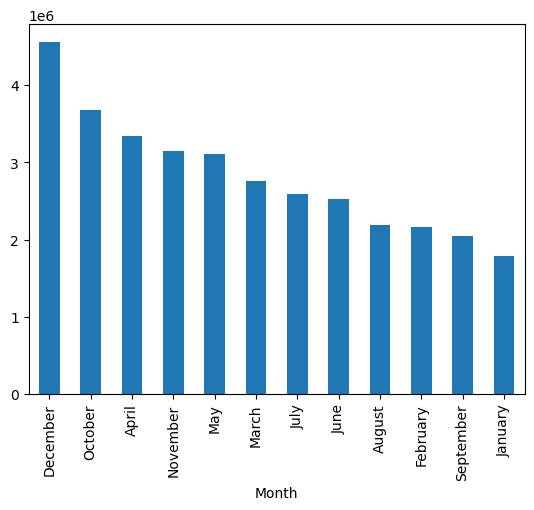

In [47]:
#grouper les chiffres d'affaires pour chaque mois et faire la somme puis classer CA
df_clean.groupby('Month')['chiffre_affaires'].sum().sort_values(ascending=False).plot.bar()

Text(0.5, 0, 'Mois')

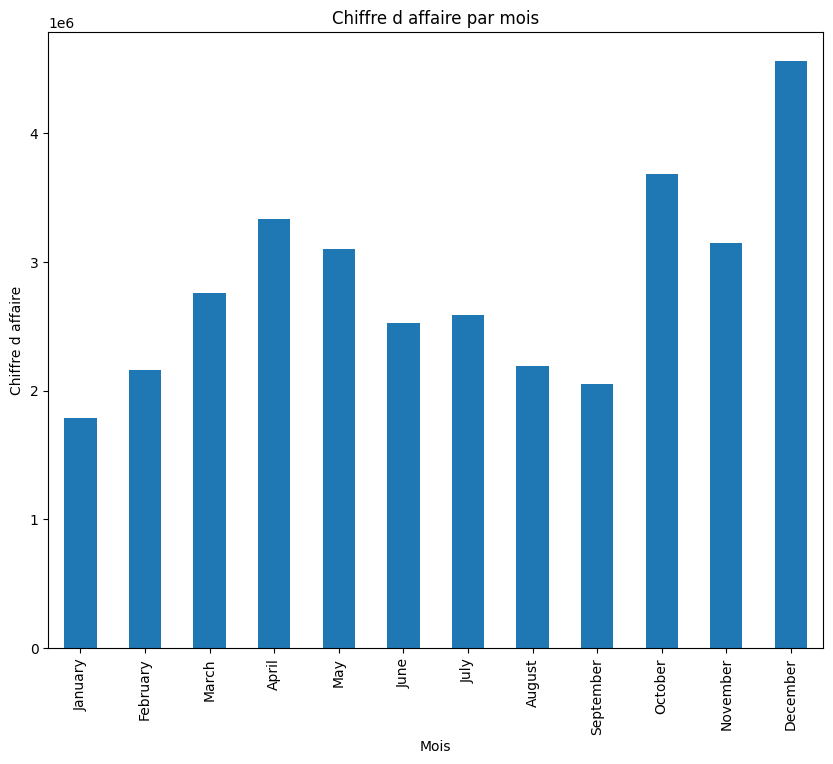

In [48]:
#Pour faire le graphe du chiffe d'affaires par mois par order des mois Jan à Dec

import matplotlib.pyplot as plt  # <-- Vérifiez bien le ".pyplot" ici

order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df_clean.groupby('Month')['chiffre_affaires'].sum().sort_index(ascending=False).loc[order].plot.bar(figsize=(10,8))

plt.title("Chiffre d affaire par mois")
plt.ylabel('Chiffre d affaire')
plt.xlabel('Mois')

In [49]:
df_clean.groupby('Month')['chiffre_affaires'].sum().sort_index(ascending=False).December

np.float64(4557905.42)

December est le meilleur mois avec un CA de 4557905.42

Dans quelle ville a-t-on le plus vendu?

In [50]:
# Pas de variable ville dans la base, mais on a Adresse
df_clean['Purchase Address'].unique() #Pour voir les modalités de ville uniques

array(['9 Lake St, New York City, NY 10001',
       '760 Church St, San Francisco, CA 94016',
       '735 5th St, New York City, NY 10001', ...,
       '731 7th St, New York City, NY 10001',
       '754 Hickory St, New York City, NY 10001',
       '657 Spruce St, New York City, NY 10001'], dtype=object)

In [51]:
'731 7th St, New York City, NY 10001'.split(',')[1].strip() #strip permet d'enlever les vides de part et d'autre d'une chaine de caractère

'New York City'

In [52]:
'760 Church St, San Francisco, CA 94016'.split(',')[1].strip()

'San Francisco'

In [53]:
def get_ville(adresse):
 return adresse.split(',')[1].strip()

In [54]:
get_ville('760 Church St, San Francisco, CA 94016')

'San Francisco'

In [55]:
df_clean['ville']= df_clean['Purchase Address'].apply(get_ville)
df_clean.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Month,Day,Year,chiffre_affaires,ville
Order Date,,,,,,,,,,
2019-01-01 03:07:00,147268,Wired Headphones,1,11.99,"9 Lake St, New York City, NY 10001",January,Tuesday,2019,11.99,New York City
2019-01-01 03:40:00,148041,USB-C Charging Cable,1,11.95,"760 Church St, San Francisco, CA 94016",January,Tuesday,2019,11.95,San Francisco
2019-01-01 04:56:00,149343,Apple Airpods Headphones,1,150.00,"735 5th St, New York City, NY 10001",January,Tuesday,2019,150.00,New York City
2019-01-01 05:53:00,149964,AAA Batteries (4-pack),1,2.99,"75 Jackson St, Dallas, TX 75001",January,Tuesday,2019,2.99,Dallas
2019-01-01 06:03:00,149350,USB-C Charging Cable,2,11.95,"943 2nd St, Atlanta, GA 30301",January,Tuesday,2019,23.90,Atlanta


In [56]:
df_clean.groupby('ville').sum()['chiffre_affaires'].sort_values(ascending=False)

,chiffre_affaires
ville,
San Francisco,8124120.94
Los Angeles,5354039.93
New York City,4581658.91
Boston,3604080.86
Atlanta,2741642.05
Dallas,2717793.72
Seattle,2693048.60
Portland,2276649.24
Austin,1786745.52


<Axes: ylabel='ville'>

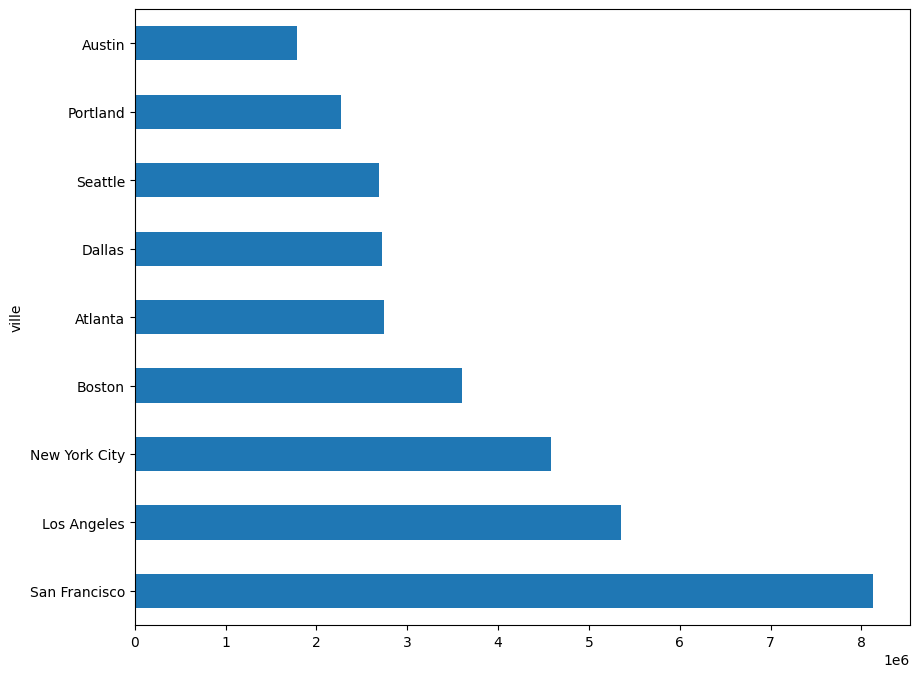

In [57]:
df_clean.groupby('ville').sum()['chiffre_affaires'].sort_values(ascending=False).plot.barh(figsize=(10,8))

A quelle heure devons-nous passer la PUB pour augmenter nos ventes ?

In [58]:
df_clean['heure'] = df_clean.index.hour
df_clean['time'] = df_clean.index.time
df_clean.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Month,Day,Year,chiffre_affaires,ville,heure,time
Order Date,,,,,,,,,,,,
2019-01-01 03:07:00,147268,Wired Headphones,1,11.99,"9 Lake St, New York City, NY 10001",January,Tuesday,2019,11.99,New York City,3,03:07:00
2019-01-01 03:40:00,148041,USB-C Charging Cable,1,11.95,"760 Church St, San Francisco, CA 94016",January,Tuesday,2019,11.95,San Francisco,3,03:40:00
2019-01-01 04:56:00,149343,Apple Airpods Headphones,1,150.00,"735 5th St, New York City, NY 10001",January,Tuesday,2019,150.00,New York City,4,04:56:00
2019-01-01 05:53:00,149964,AAA Batteries (4-pack),1,2.99,"75 Jackson St, Dallas, TX 75001",January,Tuesday,2019,2.99,Dallas,5,05:53:00
2019-01-01 06:03:00,149350,USB-C Charging Cable,2,11.95,"943 2nd St, Atlanta, GA 30301",January,Tuesday,2019,23.90,Atlanta,6,06:03:00


In [59]:
df_clean.groupby('heure')['chiffre_affaires'].sum().sort_values(ascending=False)


,chiffre_affaires
heure,
19,2370005.59
12,2269676.91
11,2267169.73
20,2242856.37
18,2176209.65
13,2118394.83
17,2086082.23
14,2045085.42
21,2013288.02


In [60]:
ca_heure = pd.DataFrame(df_clean.groupby('heure')['chiffre_affaires'].sum().sort_values(ascending=False))
ca_heure

,chiffre_affaires
heure,
19,2370005.59
12,2269676.91
11,2267169.73
20,2242856.37
18,2176209.65
13,2118394.83
17,2086082.23
14,2045085.42
21,2013288.02


<Axes: ylabel='heure'>

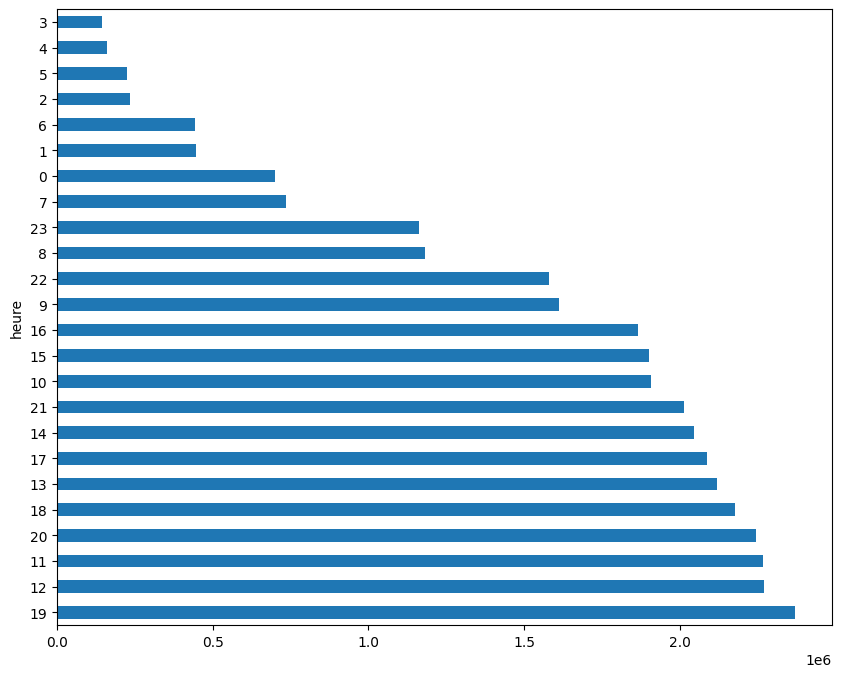

In [61]:
df_clean.groupby('heure')['chiffre_affaires'].sum().sort_values(ascending=False).plot.barh(figsize=(10,8))

<Axes: ylabel='time'>

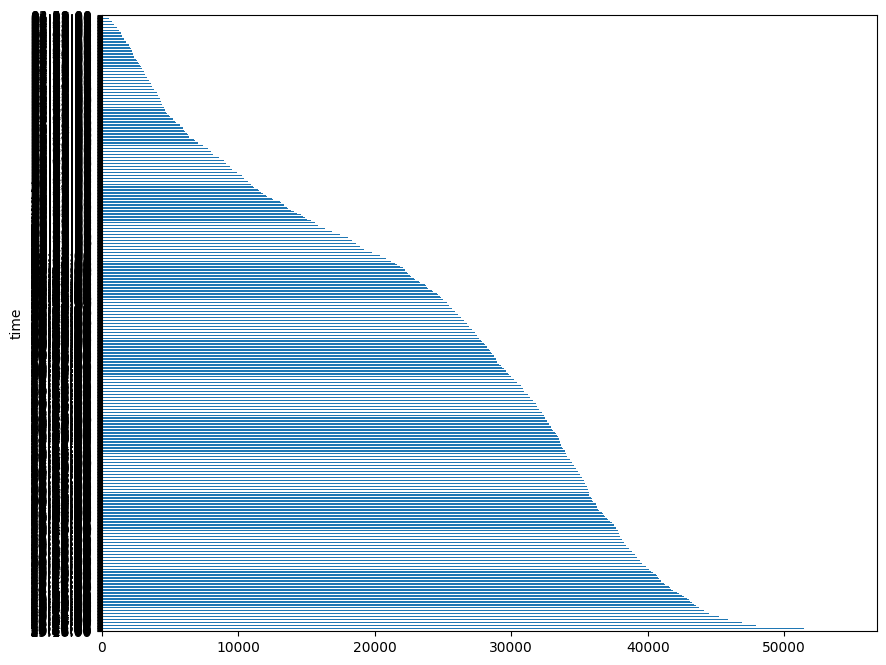

In [62]:
df_clean.groupby('time')['chiffre_affaires'].sum().sort_values(ascending=False).plot.barh(figsize=(10,8))

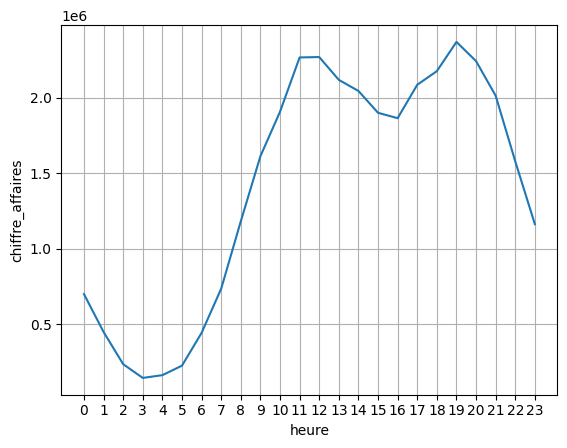

In [63]:
sns.lineplot(data = ca_heure['chiffre_affaires'])
plt.xticks(ticks=range(0, 24))
plt.grid()
plt.show()

Les produits qui sont souvent achetés ensemble ?

In [64]:
df_clean['Order ID'].duplicated() #pour voir les lignes qui sont dupliquées

,Order ID
Order Date,
2019-01-01 03:07:00,False
2019-01-01 03:40:00,False
2019-01-01 04:56:00,False
2019-01-01 05:53:00,False
2019-01-01 06:03:00,False
...,...
2020-01-01 04:13:00,False
2020-01-01 04:21:00,False
2020-01-01 04:54:00,False


In [65]:
df_m = df_clean[df_clean['Order ID'].duplicated(keep=False)].copy() #La base de données avec les duplicated , keep=False permet d'avoir toutes les occurences
df_m

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Month,Day,Year,chiffre_affaires,ville,heure,time
Order Date,,,,,,,,,,,,
2019-01-01 07:29:00,144804,Wired Headphones,1,11.99,"628 Lake St, New York City, NY 10001",January,Tuesday,2019,11.99,New York City,7,07:29:00
2019-01-01 07:29:00,144804,iPhone,1,700.00,"628 Lake St, New York City, NY 10001",January,Tuesday,2019,700.00,New York City,7,07:29:00
2019-01-01 11:25:00,148074,Google Phone,1,600.00,"6 Johnson St, Atlanta, GA 30301",January,Tuesday,2019,600.00,Atlanta,11,11:25:00
2019-01-01 11:25:00,148074,USB-C Charging Cable,1,11.95,"6 Johnson St, Atlanta, GA 30301",January,Tuesday,2019,11.95,Atlanta,11,11:25:00
2019-01-01 12:02:00,148450,iPhone,1,700.00,"761 Lakeview St, Dallas, TX 75001",January,Tuesday,2019,700.00,Dallas,12,12:02:00
...,...,...,...,...,...,...,...,...,...,...,...,...
2020-01-01 00:10:00,311386,Apple Airpods Headphones,1,150.00,"730 Pine St, San Francisco, CA 94016",January,Wednesday,2020,150.00,San Francisco,0,00:10:00
2020-01-01 00:22:00,297817,Lightning Charging Cable,2,14.95,"519 13th St, New York City, NY 10001",January,Wednesday,2020,29.90,New York City,0,00:22:00
2020-01-01 00:22:00,297817,iPhone,1,700.00,"519 13th St, New York City, NY 10001",January,Wednesday,2020,700.00,New York City,0,00:22:00


In [66]:
#définir une fonction pour regrouper dans une seule cellule de texte tous les produits achetés lors d'une même commande
def concat_produit_par_order_id(p : list):    #L'indication : list est une notation (type hint) qui précise que p doit être une liste de textes (ex: ['iPhone', 'Lightning Charging Cable']).
  return ",".join(p)

In [67]:
ensemble = df_m.groupby('Order ID')['Product'].apply(concat_produit_par_order_id)
ensemble

,Product
Order ID,
141275,"USB-C Charging Cable,Wired Headphones"
141290,"Apple Airpods Headphones,AA Batteries (4-pack)"
141365,"Wired Headphones,Vareebadd Phone"
141384,"USB-C Charging Cable,Google Phone"
141450,"Bose SoundSport Headphones,Google Phone"
...,...
319536,"Wired Headphones,Macbook Pro Laptop"
319556,"Google Phone,Wired Headphones"
319584,"iPhone,Wired Headphones"


In [92]:
from itertools import combinations
from collections import Counter
count = Counter()
for achat in ensemble.to_list():
  products = achat.split(';')
  print(products)
  count.update(Counter(combinations(products, 2)))
count

In [93]:
count = Counter()

In [94]:
list(combinations(['a', 'b', 'c', 'e'], 3))

[('a', 'b', 'c'), ('a', 'b', 'e'), ('a', 'c', 'e'), ('b', 'c', 'e')]

In [95]:
Counter(combinations(['a', 'b', 'c', 'e'], 3))

Counter({('a', 'b', 'c'): 1,
         ('a', 'b', 'e'): 1,
         ('a', 'c', 'e'): 1,
         ('b', 'c', 'e'): 1})

In [96]:
ensemble.to_list()

['USB-C Charging Cable,Wired Headphones',
 'Apple Airpods Headphones,AA Batteries (4-pack)',
 'Wired Headphones,Vareebadd Phone',
 'USB-C Charging Cable,Google Phone',
 'Bose SoundSport Headphones,Google Phone',
 'Apple Airpods Headphones,iPhone',
 'Google Phone,Apple Airpods Headphones',
 'iPhone,Apple Airpods Headphones,Wired Headphones',
 'Apple Airpods Headphones,USB-C Charging Cable',
 'Wired Headphones,Lightning Charging Cable',
 'iPhone,Lightning Charging Cable',
 '27in FHD Monitor,Bose SoundSport Headphones',
 'USB-C Charging Cable,Google Phone',
 'Wired Headphones,iPhone',
 'Google Phone,USB-C Charging Cable',
 'AA Batteries (4-pack),AAA Batteries (4-pack)',
 'Vareebadd Phone,Wired Headphones,USB-C Charging Cable',
 'USB-C Charging Cable,Google Phone',
 'Vareebadd Phone,Wired Headphones',
 'Lightning Charging Cable,34in Ultrawide Monitor',
 'USB-C Charging Cable,Wired Headphones',
 'Lightning Charging Cable,Bose SoundSport Headphones',
 'Wired Headphones,Google Phone',
 'Wired

In [97]:
for achat in ensemble.to_list():
  products = achat.split(';')
  print(products)
  count.update(Counter(combinations(products, 2)))

['USB-C Charging Cable,Wired Headphones']
['Apple Airpods Headphones,AA Batteries (4-pack)']
['Wired Headphones,Vareebadd Phone']
['USB-C Charging Cable,Google Phone']
['Bose SoundSport Headphones,Google Phone']
['Apple Airpods Headphones,iPhone']
['Google Phone,Apple Airpods Headphones']
['iPhone,Apple Airpods Headphones,Wired Headphones']
['Apple Airpods Headphones,USB-C Charging Cable']
['Wired Headphones,Lightning Charging Cable']
['iPhone,Lightning Charging Cable']
['27in FHD Monitor,Bose SoundSport Headphones']
['USB-C Charging Cable,Google Phone']
['Wired Headphones,iPhone']
['Google Phone,USB-C Charging Cable']
['AA Batteries (4-pack),AAA Batteries (4-pack)']
['Vareebadd Phone,Wired Headphones,USB-C Charging Cable']
['USB-C Charging Cable,Google Phone']
['Vareebadd Phone,Wired Headphones']
['Lightning Charging Cable,34in Ultrawide Monitor']
['USB-C Charging Cable,Wired Headphones']
['Lightning Charging Cable,Bose SoundSport Headphones']
['Wired Headphones,Google Phone']
['Wired

In [99]:
count

Counter()

In [103]:
from itertools import combinations
from collections import Counter
count = Counter()
for achat in ensemble.to_list():
  products = achat.split(',')
  print(products)
  count.update(Counter(combinations(products, 2)))
count

['USB-C Charging Cable', 'Wired Headphones']
['Apple Airpods Headphones', 'AA Batteries (4-pack)']
['Wired Headphones', 'Vareebadd Phone']
['USB-C Charging Cable', 'Google Phone']
['Bose SoundSport Headphones', 'Google Phone']
['Apple Airpods Headphones', 'iPhone']
['Google Phone', 'Apple Airpods Headphones']
['iPhone', 'Apple Airpods Headphones', 'Wired Headphones']
['Apple Airpods Headphones', 'USB-C Charging Cable']
['Wired Headphones', 'Lightning Charging Cable']
['iPhone', 'Lightning Charging Cable']
['27in FHD Monitor', 'Bose SoundSport Headphones']
['USB-C Charging Cable', 'Google Phone']
['Wired Headphones', 'iPhone']
['Google Phone', 'USB-C Charging Cable']
['AA Batteries (4-pack)', 'AAA Batteries (4-pack)']
['Vareebadd Phone', 'Wired Headphones', 'USB-C Charging Cable']
['USB-C Charging Cable', 'Google Phone']
['Vareebadd Phone', 'Wired Headphones']
['Lightning Charging Cable', '34in Ultrawide Monitor']
['USB-C Charging Cable', 'Wired Headphones']
['Lightning Charging Cable',

Counter({('USB-C Charging Cable', 'Wired Headphones'): 101,
         ('Apple Airpods Headphones', 'AA Batteries (4-pack)'): 37,
         ('Wired Headphones', 'Vareebadd Phone'): 82,
         ('USB-C Charging Cable', 'Google Phone'): 474,
         ('Bose SoundSport Headphones', 'Google Phone'): 115,
         ('Apple Airpods Headphones', 'iPhone'): 159,
         ('Google Phone', 'Apple Airpods Headphones'): 11,
         ('iPhone', 'Apple Airpods Headphones'): 196,
         ('iPhone', 'Wired Headphones'): 236,
         ('Apple Airpods Headphones', 'Wired Headphones'): 48,
         ('Apple Airpods Headphones', 'USB-C Charging Cable'): 24,
         ('Wired Headphones', 'Lightning Charging Cable'): 70,
         ('iPhone', 'Lightning Charging Cable'): 509,
         ('27in FHD Monitor', 'Bose SoundSport Headphones'): 13,
         ('Wired Headphones', 'iPhone'): 216,
         ('Google Phone', 'USB-C Charging Cable'): 492,
         ('AA Batteries (4-pack)', 'AAA Batteries (4-pack)'): 45,
       

In [104]:
count.most_common(10)

[(('iPhone', 'Lightning Charging Cable'), 509),
 (('Google Phone', 'USB-C Charging Cable'), 492),
 (('USB-C Charging Cable', 'Google Phone'), 474),
 (('Lightning Charging Cable', 'iPhone'), 474),
 (('iPhone', 'Wired Headphones'), 236),
 (('Wired Headphones', 'iPhone'), 216),
 (('Wired Headphones', 'Google Phone'), 215),
 (('iPhone', 'Apple Airpods Headphones'), 196),
 (('Google Phone', 'Wired Headphones'), 195),
 (('Vareebadd Phone', 'USB-C Charging Cable'), 188)]

Produit le plus vendu

In [105]:
df_clean.groupby('Product')['Quantity Ordered'].sum().sort_values(ascending=False)

,Quantity Ordered
Product,
AAA Batteries (4-pack),30487
AA Batteries (4-pack),27148
USB-C Charging Cable,23555
Lightning Charging Cable,22841
Wired Headphones,20201
Apple Airpods Headphones,15383
Bose SoundSport Headphones,13236
27in FHD Monitor,7429
iPhone,6732
